In [ ]:

import os
import ast
import pandas as pd
import random
import csv
from typing import Literal
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

# Set API key manually
os.environ["ANTHROPIC_API_KEY"] = ""

train_set_16 = pd.read_csv('//home/s6moakba/InstructABSA/Dataset/SemEval16/Train/Restaurants_Train.csv')
train_set_16['aspectTerms'] = train_set_16['aspectTerms'].apply(ast.literal_eval)
train_set_16['aspect'] = train_set_16['aspectTerms'].apply(lambda x: [d['term'] for d in x])
train_set_16['polarity'] = train_set_16['aspectTerms'].apply(lambda x: [d['polarity'] for d in x])
training_terms = set(aspect for sublist in train_set_16['aspect'] for aspect in sublist)
training_terms.discard('noaspectterm')

llm = ChatAnthropic(
    model="claude-3-5-sonnet-latest",
    api_key=os.getenv("ANTHROPIC_API_KEY"),
    temperature=0.2,
    max_tokens=1024
)

import random
def get_aspect():
        terms = random.sample(list(training_terms), 1)
        return terms


class SentenceGen(BaseModel):
    sentence: str = Field(None, description="The generated sentence.")
    Terms: str = Field(None, description="The aspect term used.")

structured_llm_gen = llm.with_structured_output(SentenceGen)

class SentenceEval(BaseModel):
    Eval: Literal['OK', 'NOT_OK'] = Field(None, description="Evaluation result.")
    Feedback: str = Field(None, description="Improvement suggestions if NOT_OK.")

structured_llm_eval = llm.with_structured_output(SentenceEval)

@tool
def generate_sentences() -> str:
    """Generates a sentence containing an aspect term."""
    terms = get_aspect()
    print('Selected terms:', terms)
    prompt = f"""Generate a sentence using this aspect term: {', '.join(terms)}.
    Respond **only** with the sentence. Do not include explanations."""
    response = structured_llm_gen.invoke(prompt)
    print('Sentence generated')
    return response

@tool
def fix_sentence(text: str) -> str:
    """Fixes a sentence based on evaluator feedback."""
    print('Fixing sentence')
    prompt = f"""Improve the following sentence based on the provided feedback:
    {text}
    Respond **only** with the improved sentence. Do not include explanations."""
    fixed_sentence = llm.invoke(prompt)
    return fixed_sentence.content.strip()

# Evaluator tool
@tool
def evaluate_sentence(text: str) -> str:
    """Evaluates a generated sentence."""
    print('Evaluating sentence')
    prompt = f"""Evaluate the following sentence:
    {text}
    Respond **only** with 'OK' if the sentence is good, or 'NOT_OK' if it needs improvement.
    If 'NOT_OK', provide specific feedback on how to improve it."""
    return structured_llm_eval.invoke(prompt)


generator_agent = create_react_agent(
    llm,
    tools=[generate_sentences, fix_sentence],
    prompt="""You are a sentence generator. You can generate a new sentence or fix a sentence based on feedback.
    If feedback is given, use the `fix_sentence` tool to improve it.
    If no feedback is provided, use `generate_sentences` to create a new sentence."""
)

evaluator_agent = create_react_agent(
    llm,
    tools=[evaluate_sentence],
    prompt="You are an evaluator. Evaluate the given sentence and determine if it is OK or needs improvement."
)

import re
def generator_node(state: MessagesState):
    """Node for generating or fixing sentences."""
    last_message = state["messages"][-1] if state["messages"] else None

    if last_message and last_message.name == "evaluator":
        # Feedback detected, generator should fix the sentence
        result = generator_agent.invoke({"messages": [HumanMessage(content=last_message.content)]})
    else:
        # No feedback, generate a new sentence
        result = generator_agent.invoke({"messages": [HumanMessage(content="Generate a new sentence.")]})

    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="generator")
    return {"messages": result["messages"]}

def evaluator_node(state: MessagesState):
    """Node that evaluates the generated sentence."""
    result = evaluator_agent.invoke(state)

    eval_response = result["messages"][-1].content.strip()

    try:
        eval_result = structured_llm_eval.invoke(eval_response)
    except Exception as e:
        print(f"[Evaluator Node] Error parsing evaluation response: {e}")
        return {"messages": state["messages"]}  

    if eval_result.Eval == "OK":
        final_sentence = state["messages"][-2].content  
        return {"messages": state["messages"] + [HumanMessage(content=f"Final Approved Sentence: {final_sentence}", name="evaluator")]}

    return {"messages": state["messages"] + [HumanMessage(content=eval_result.Feedback, name="evaluator")]}


def saver_node(state: MessagesState):
    """Node that saves the final approved sentence and its aspect term to a CSV file."""
    last_message = state["messages"][-1].content

    if last_message.startswith("Final Approved Sentence:"):
        final_sentence = last_message.replace("Final Approved Sentence: ", "").strip()
    else:
        return {"messages": state["messages"]}

    message_content = last_message.replace("Final Approved Sentence: ", "").strip()

    # Extract aspect term using regex (Assuming it follows a pattern like Terms='some term')
    if " Terms=" in message_content:
        sentence_part, terms_part = message_content.split(" Terms=", 1)
        
        # Remove sentence='...' structure
        final_sentence = sentence_part.replace("sentence=", "").strip().strip("'\"")
        aspect_term = terms_part.strip().strip("'\"")
    else:
        # Fallback if splitting fails
        final_sentence = message_content.strip().strip("'\"")
        aspect_term = "Unknown Terms"

    csv_file = "approved_sentences.csv"

    # Ensure the file has headers if it does not exist
    file_exists = os.path.isfile(csv_file)

    with open(csv_file, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["sentence", "Terms"])  # Write headers if new file
        writer.writerow([final_sentence, aspect_term])

    print(f"[Saver Node] Sentence saved: {final_sentence} | Aspect Term: {aspect_term}")

    return {"messages": state["messages"]}

def evaluation_decision(state: MessagesState):
    """Decides whether to loop back to generator or proceed to saver node."""
    last_message = state["messages"][-1].content.strip()

    if last_message.startswith("Final Approved Sentence:"):
        return "saver"  # Route to saver_node

    return "generator"

# Build the graph
graph = StateGraph(MessagesState)

graph.add_node("generator", generator_node)
graph.add_node("evaluator", evaluator_node)
graph.add_node("saver", saver_node)  # Saver node added

graph.set_entry_point("generator")  # Entry point

graph.add_edge("generator", "evaluator")
graph.add_conditional_edges("evaluator", evaluation_decision, {"generator": "generator", "saver": "saver"})
graph.add_edge("saver", END)  # Saver node leads to END

graph = graph.compile()

messages = graph.invoke({"messages": [ HumanMessage(content="Generate a sentences for me using your agents.")]},{"recursion_limit": 150})
for m in messages["messages"]:
    m.pretty_print()


Selected terms: ['frontman']
Sentence generated
Evaluating sentence
[Saver Node] Sentence saved: The charismatic frontman captivated the audience with his powerful vocals and magnetic stage presence. | Aspect Term: frontman
================================ Human Message =================================

Generate a sentences for me using your agents.
================================ Human Message =================================

Generate a new sentence.
================================== Ai Message ==================================

[{'text': "I'll help you generate a new sentence using the `generate_sentences` tool.", 'type': 'text'}, {'id': 'toolu_01RTGG9fEMEq7PZMp5ha76qo', 'input': {}, 'name': 'generate_sentences', 'type': 'tool_use'}]
Tool Calls:
  generate_sentences (toolu_01RTGG9fEMEq7PZMp5ha76qo)
 Call ID: toolu_01RTGG9fEMEq7PZMp5ha76qo
  Args:
================================= Tool Message =================================
Name: generate_sentences

sentence='The charismatic 

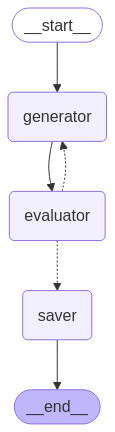

In [3]:
from IPython.display import clear_output
from IPython.display import Image
clear_output(wait=True)  # Clear previous outputs
display(Image(graph.get_graph().draw_mermaid_png()))